In [47]:
# Herramienta de Selección de ROIs
import cv2
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, FloatSlider, Dropdown, Button, HBox, VBox, Output
from IPython.display import display

path_imagenes = "/Users/brianfuentes/Downloads/004/*.jpg" 

#  Cargar imagen de referencia
files = sorted(glob.glob(path_imagenes))
# Filtro anti-archivos basura de Mac
valid_files = [f for f in files if not os.path.basename(f).startswith("._")]

if not valid_files:
    print(" Error: No se encontraron imágenes. Revisa la ruta.")
else:
    # Leemos la primera imagen
    img_bgr = cv2.imread(valid_files[0])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Para matplotlib
    H, W, _ = img_rgb.shape

    # Definición inicial de ROIs (Centro X, Centro Y, Ancho%, Alto%)
    # Valores normalizados de 0.0 a 1.0
    roi_dict = {
        "ANCLA":  [0.3, 0.5, 0.1, 0.1],  # Una zona inicial
        "TINTE1": [0.2, 0.5, 0.15, 0.2],
        "TINTE2": [0.7, 0.5, 0.15, 0.2]
    }

    out = Output()

    def draw_overlay(sel=None):
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.imshow(img_rgb)
            
            for name, (cx, cy, wr, hr) in roi_dict.items():
                # Convertir de relativo (0-1) a píxeles
                wpx = int(W * wr)
                hpx = int(H * hr)
                x_center = int(W * cx)
                y_center = int(H * cy)
                
                # Matplotlib usa esquina superior izquierda
                x0 = x_center - wpx // 2
                y0 = y_center - hpx // 2
                
                col = "yellow" if name == sel else "red"
                thick = 3 if name == sel else 1
                alpha = 1.0 if name == sel else 0.6
                
                rect = patches.Rectangle((x0, y0), wpx, hpx, fill=False, lw=thick, edgecolor=col, alpha=alpha)
                ax.add_patch(rect)
                ax.text(x0, y0 - 5, name, color=col, fontsize=9, weight="bold",
                        bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))
            
            ax.set_title(f"Ajustando: {sel}")
            ax.axis("off")
            plt.show()

    # Controles
    roi_names = list(roi_dict.keys())
    dd = Dropdown(options=roi_names, value=roi_names[0], description="ROI Activa:")
    
    # Sliders (cx=centro X, cy=centro Y, w=ancho, h=alto)
    sx = FloatSlider(description="Pos X", min=0.0, max=1.0, step=0.002, value=roi_dict[dd.value][0])
    sy = FloatSlider(description="Pos Y", min=0.0, max=1.0, step=0.002, value=roi_dict[dd.value][1])
    sw = FloatSlider(description="Ancho", min=0.01, max=0.4, step=0.002, value=roi_dict[dd.value][2])
    sh = FloatSlider(description="Alto", min=0.01, max=0.4, step=0.002, value=roi_dict[dd.value][3])
    
    btn = Button(description="IMPRIMIR COORDENADAS", button_style="success", icon="check")

    def on_change(*args):
        # Actualizar diccionario con valores de sliders
        roi_dict[dd.value] = [sx.value, sy.value, sw.value, sh.value]
        draw_overlay(sel=dd.value)

    def on_select(change):
        # Actualizar sliders con valores del diccionario
        vals = roi_dict[dd.value]
        sx.value, sy.value, sw.value, sh.value = vals
        draw_overlay(sel=dd.value)

    def on_print(b):
        print("COORDENADAS")
        for name, (cx, cy, wr, hr) in roi_dict.items():
            # Convertimos a formato [x, y, w, h] (Top-Left) para OpenCV
            wpx = int(W * wr)
            hpx = int(H * hr)
            x0 = int((W * cx) - (wpx // 2))
            y0 = int((H * cy) - (hpx // 2))
            # Corregir si se sale de la imagen (<0)
            x0 = max(0, x0)
            y0 = max(0, y0)
            
            var_name = "ROI_" + name
            print(f"{var_name} = [{x0}, {y0}, {wpx}, {hpx}]")
    

    dd.observe(on_select, names="value")
    sx.observe(on_change, names="value")
    sy.observe(on_change, names="value")
    sw.observe(on_change, names="value")
    sh.observe(on_change, names="value")
    btn.on_click(on_print)

    ui = VBox([dd, HBox([sx, sy]), HBox([sw, sh]), btn, out])
    display(ui)
    draw_overlay(sel=dd.value)

# --- COORDENADAS COPIADAS ---
ROI_ANCLA = [535, 80, 35, 27]
ROI_TINTE1 = [156, 312, 96, 96]
ROI_TINTE2 = [400, 192, 96, 96]
# ----------------------------



Analizando CICLO 3...
   (Leyendo desde la imagen 610 hasta 915)
   Procesando ciclo 3 | Foto relativa 0 -> 22.1°C
   Procesando ciclo 3 | Foto relativa 50 -> 29.3°C
   Procesando ciclo 3 | Foto relativa 100 -> 36.4°C
   Procesando ciclo 3 | Foto relativa 150 -> 43.3°C
   Procesando ciclo 3 | Foto relativa 200 -> 37.0°C
   Procesando ciclo 3 | Foto relativa 250 -> 29.8°C
   Procesando ciclo 3 | Foto relativa 300 -> 22.7°C


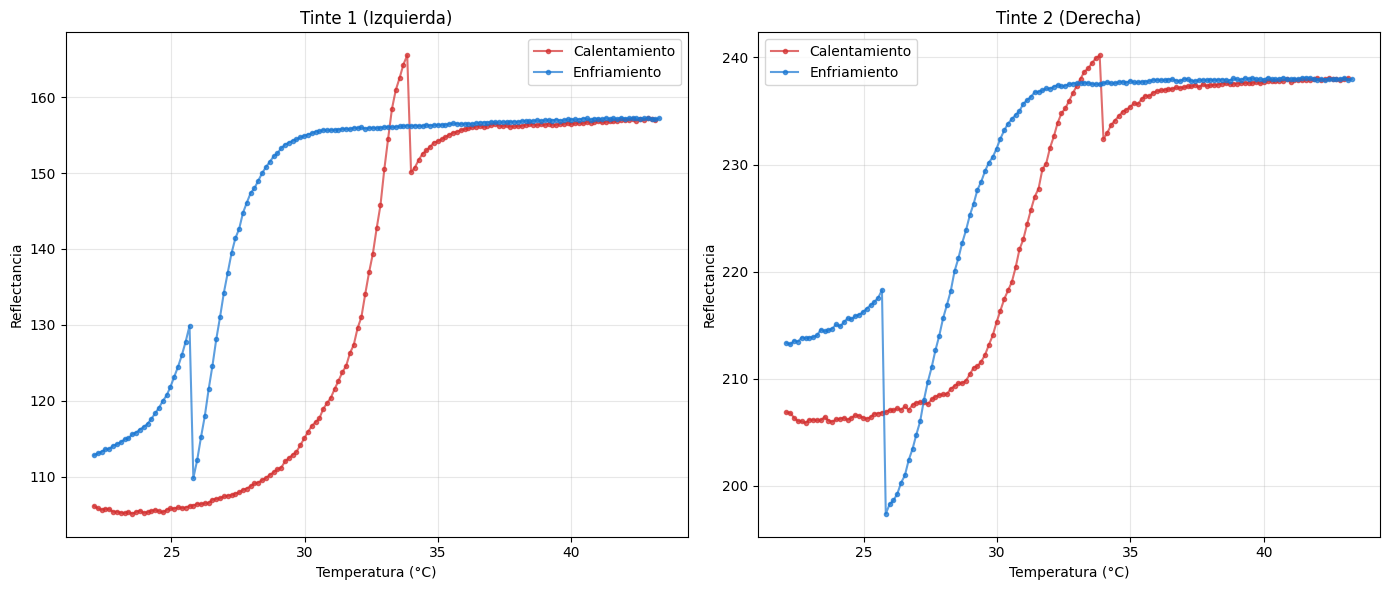

In [51]:
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

#COORDENADAS

ROI_ANCLA = [535, 80, 35, 27]
ROI_TINTE1 = [156, 312, 96, 96]
ROI_TINTE2 = [400, 192, 96, 96]

# Datos
path_imagenes = "/Users/brianfuentes/Downloads/004/*.jpg" 

TOTAL_IMAGENES = 917
NUM_CICLOS = 3
T_INICIAL = 22.1
T_FINAL = 33.4
FOTOS_EN_MESETA = 8

# Cálculos de tiempo/temperatura
fotos_por_ciclo = TOTAL_IMAGENES // NUM_CICLOS 
fotos_rampa = (fotos_por_ciclo - FOTOS_EN_MESETA) // 2
delta_T = T_FINAL - T_INICIAL
step = delta_T / fotos_rampa

#  CARGA DE IMÁGENES 
raw_files = sorted(glob.glob(path_imagenes))
archivos = [f for f in raw_files if not os.path.basename(f).startswith("._")]

if not archivos:
    raise SystemExit(" Error: No se encontraron imágenes.")

# Preparar Template de Alineación (Ancla)
img_base = cv2.imread(archivos[0], cv2.IMREAD_GRAYSCALE)
alto, ancho = img_base.shape
xa, ya, wa, ha = ROI_ANCLA
template = img_base[ya:ya+ha, xa:xa+wa] # Recorte de la mancha negra

# ROCESAMIENTO 
# CONFIGURACIÓN DEL CICLO A ANALIZAR
CICLO_A_ANALIZAR = 3
offset_inicio = (CICLO_A_ANALIZAR - 1) * fotos_por_ciclo

print(f"\nAnalizando CICLO {CICLO_A_ANALIZAR}...")
print(f"   (Leyendo desde la imagen {offset_inicio} hasta {offset_inicio + fotos_por_ciclo})")

temps, fases = [], []
ref_m1, ref_m2 = [], []

# Usamos 'i' como el tiempo RELATIVO dentro del ciclo 
for i in range(fotos_por_ciclo):
    
    # es el número real del archivo en la carpeta (foto 309, 310, etc.)
    idx_real = offset_inicio + i
    
    #  Si se acaban las fotos, parar
    if idx_real >= len(archivos): 
        print("⚠️ Fin de archivos alcanzado.")
        break
    
    # Calcular Temperatura (Usamos 'i' relativo para reiniciar la rampa)
    if i < fotos_rampa: 
        t = T_INICIAL + (i * step)
        fase = "Calentamiento"
    elif i < (fotos_rampa + FOTOS_EN_MESETA):
        t = T_FINAL
        fase = "Meseta"
    else:
        steps_bajada = i - (fotos_rampa + FOTOS_EN_MESETA)
        t = T_FINAL - (steps_bajada * step)
        fase = "Enfriamiento"
    
    #procesar Imagen 
    img = cv2.imread(archivos[idx_real], cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # Alineacion
    res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
    _, _, _, max_loc = cv2.minMaxLoc(res)
    dx = xa - max_loc[0]
    dy = ya - max_loc[1]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    img_al = cv2.warpAffine(img, M, (ancho, alto))
    
    # 2.Medicion
    x1, y1, w1, h1 = ROI_TINTE1
    x2, y2, w2, h2 = ROI_TINTE2
    
    val1 = np.mean(img_al[y1:y1+h1, x1:x1+w1])
    val2 = np.mean(img_al[y2:y2+h2, x2:x2+w2])
    
    temps.append(t)
    fases.append(fase)
    ref_m1.append(val1)
    ref_m2.append(val2)

    if i % 50 == 0:
        print(f"   Procesando ciclo {CICLO_A_ANALIZAR} | Foto relativa {i} -> {t:.1f}°C")
# Graficas
df = pd.DataFrame({'Temp': temps, 'Fase': fases, 'Ref1': ref_m1, 'Ref2': ref_m2})
df.to_csv("datos_termocromicos.csv", index=False)

plt.figure(figsize=(14, 6))

# Tinte 1
plt.subplot(1, 2, 1)
sub = df[df['Fase']=='Calentamiento']
baj = df[df['Fase']=='Enfriamiento']
plt.plot(sub['Temp'], sub['Ref1'], 'o-', color='#D32F2F', label='Calentamiento', markersize=3, alpha=0.7)
plt.plot(baj['Temp'], baj['Ref1'], 'o-', color='#1976D2', label='Enfriamiento', markersize=3, alpha=0.7)
plt.title("Tinte 1 (Izquierda)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Reflectancia")
plt.legend()
plt.grid(True, alpha=0.3)

# Tinte 2
plt.subplot(1, 2, 2)
plt.plot(sub['Temp'], sub['Ref2'], 'o-', color='#D32F2F', label='Calentamiento', markersize=3, alpha=0.7)
plt.plot(baj['Temp'], baj['Ref2'], 'o-', color='#1976D2', label='Enfriamiento', markersize=3, alpha=0.7)
plt.title("Tinte 2 (Derecha)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Reflectancia")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
